<a href="https://colab.research.google.com/github/Rabelani-byte/MIT805-Big-Data-Project/blob/main/notebooks/Part_2_PySpark_MapReduce_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIT 805 Part 2 — PySpark MapReduce and Visualisation

**Dataset:** Amazon Reviews 2023 — Clothing, Shoes and Jewelry  
**Processing dataset:** the same 3 GiB JSONL subset used in Part 1  
**Main question:** *Which products show the highest customer risk when we consider the number of reviews, negative reviews, helpful votes on negative reviews, and changes in ratings over time?*

PySpark is used for all large-scale processing. Pandas is used only for small result tables that are ready for plotting.


## Objectives and reason for the analysis

This analysis has five objectives:

1. prepare the review data for analysis;
2. group millions of reviews by parent product using PySpark;
3. compare historical ratings (up to 2020) with recent ratings (2021–2023);
4. calculate a simple risk score for products with enough reviews; and
5. use the results to identify products that may need further investigation.

Only products with at least **50 reviews** are ranked. In Part 1, the 99th percentile was 48 reviews per product. Using 50 reviews therefore focuses the analysis on products with more review evidence and avoids ranking products with only one or two reviews. This is a ranking rule, not a statistical significance test.


In [ ]:
!pip -q install pyspark==4.0.0 huggingface-hub matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.1/434.1 MB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json, math, os, platform

from huggingface_hub import HfApi, hf_hub_download
from pyspark.sql import SparkSession, functions as F, types as T, Window
import matplotlib.pyplot as plt
import seaborn as sns

spark = (SparkSession.builder
         .appName("MIT805-Part2-Amazon-Review-Risk")
         .config("spark.sql.shuffle.partitions", "24")
         .config("spark.driver.memory", "10g")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

ROOT = Path("/content/mit805_part2")
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "output"
FIGURE_DIR = ROOT / "figures"
for folder in (RAW_DIR, PROCESSED_DIR, OUTPUT_DIR, FIGURE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print("Run time (UTC):", datetime.now(timezone.utc).isoformat())
print("Python:", platform.python_version())
print("Spark:", spark.version)
print("Spark UI:", spark.sparkContext.uiWebUrl)
print("Storage:", ROOT)

Run time (UTC): 2026-10-06T14:13:35.220202+00:00
Python: 3.13.15
Spark: 4.0.0
Spark UI: http://2352a27ee3b6:4040
Storage: /content/mit805_part2


## Prepare the processing data

This notebook uses the same 3 GiB processing dataset used in Part 1.

If the processing file already exists, it can be reused. Otherwise, the full dataset is downloaded and complete JSONL records are copied until the processing file reaches at least 3 GiB.

Complete lines are copied so that no JSON record is cut in half.


In [ ]:
REPO_ID = "McAuley-Lab/Amazon-Reviews-2023"
HF_FILENAME = "raw/review_categories/Clothing_Shoes_and_Jewelry.jsonl"
MIN_PROCESSING_BYTES = 3 * 1024**3

api = HfApi()
info = api.dataset_info(REPO_ID, files_metadata=True)
entry = next(s for s in info.siblings if s.rfilename == HF_FILENAME)
hosted_bytes = entry.size
assert 25 <= hosted_bytes / 1e9 <= 40
print(f"Hosted raw file: {hosted_bytes:,} bytes ({hosted_bytes/1e9:.3f} GB)")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Hosted raw file: 27,810,080,533 bytes (27.810 GB)


In [ ]:
downloaded = hf_hub_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    filename=HF_FILENAME,
    local_dir=RAW_DIR,
)
RAW_PATH = Path(downloaded)
raw_bytes = RAW_PATH.stat().st_size
assert raw_bytes >= 12e9
print(f"Working file: {raw_bytes:,} bytes ({raw_bytes/1e9:.3f} GB)")

raw/review_categories/Clothing_Shoes_and(…): reconstructing file:   0%|          |  0.00B / 27.8GB            

raw/review_categories/Clothing_Shoes_and(…): downloading bytes:           |  0.00B            

Working file: 27,810,080,533 bytes (27.810 GB)


In [ ]:
PROCESSING_PATH = PROCESSED_DIR / "Clothing_Shoes_and_Jewelry_3GiB.jsonl"
if not PROCESSING_PATH.exists() or PROCESSING_PATH.stat().st_size < MIN_PROCESSING_BYTES:
    copied = 0
    with RAW_PATH.open("rb") as source, PROCESSING_PATH.open("wb") as target:
        while copied < MIN_PROCESSING_BYTES:
            line = source.readline()
            if not line:
                break
            target.write(line)
            copied += len(line)

processing_bytes = PROCESSING_PATH.stat().st_size
assert processing_bytes >= MIN_PROCESSING_BYTES
print(f"Processing file: {processing_bytes:,} bytes ({processing_bytes/1e9:.3f} GB; {processing_bytes/1024**3:.3f} GiB)")

Processing file: 3,221,225,482 bytes (3.221 GB; 3.000 GiB)


## Mapping and transformation

This step prepares the reviews for analysis.

Spark converts columns to the correct data types, removes records with invalid product IDs or ratings, and creates new variables. For example, `is_negative` identifies 1- and 2-star reviews, while `period` separates historical and recent reviews.

`log1p_helpful` reduces the effect of extremely large helpful-vote values without removing those reviews.

The data are split into 24 partitions and cached because they are used several times later. The full dataset is not converted to Pandas.


In [ ]:
reviews_raw = spark.read.json(str(PROCESSING_PATH))

reviews = (reviews_raw
          .select("parent_asin", "user_id", "rating", "helpful_vote", "verified_purchase", "timestamp", "text")
          .withColumn("rating", F.col("rating").cast("double"))
          .withColumn("helpful_vote", F.col("helpful_vote").cast("long"))
          .withColumn("timestamp", F.col("timestamp").cast("long"))
          .withColumn("review_time", F.to_timestamp(F.from_unixtime(F.col("timestamp") / 1000)))
          .withColumn("review_year", F.year("review_time"))
          .filter(F.col("parent_asin").isNotNull() & F.col("rating").between(1, 5))
          .withColumn("is_negative", (F.col("rating") <= 2).cast("long"))
          .withColumn("is_positive", (F.col("rating") >= 4).cast("long"))
          .withColumn("verified_flag", F.col("verified_purchase").cast("long"))
          .withColumn("negative_helpful", F.when(F.col("rating") <= 2, F.col("helpful_vote")).otherwise(F.lit(0)))
          .withColumn("log1p_helpful", F.log1p(F.greatest(F.col("helpful_vote"), F.lit(0))))
          .withColumn("period", F.when(F.col("review_year") <= 2020, F.lit("historical")).otherwise(F.lit("recent")))
          .repartition(24, "parent_asin")
          .cache())

processing_rows = reviews.count()
print(f"Valid processing rows: {processing_rows:,}")
reviews.printSchema()

Valid processing rows: 7,231,543
root
 |-- parent_asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- text: string (nullable = true)
 |-- review_time: timestamp (nullable = true)
 |-- review_year: integer (nullable = true)
 |-- is_negative: long (nullable = true)
 |-- is_positive: long (nullable = true)
 |-- verified_flag: long (nullable = true)
 |-- negative_helpful: long (nullable = true)
 |-- log1p_helpful: double (nullable = true)
 |-- period: string (nullable = false)



## Map → Shuffle → Reduce

This section shows the MapReduce process directly.

- **Map:** each review is changed into a `(product, values)` pair.
- **Shuffle:** `reduceByKey()` moves data so that reviews with the same product ID can be processed together.
- **Reduce:** the values for each product are added together to calculate totals such as review count, rating sum and negative-review count.

We later compare these RDD results with the DataFrame results to check that both methods give the same answer. The main analysis uses Spark DataFrames because they are easier to work with and Spark can optimise their execution.


In [ ]:
mapped_pairs = reviews.select(
    "parent_asin", "rating", "is_negative", "negative_helpful", "verified_flag"
).rdd.map(lambda r: (
    r.parent_asin,
    (1, float(r.rating), int(r.is_negative), int(r.negative_helpful or 0), int(r.verified_flag or 0))
))

reduced_pairs = mapped_pairs.reduceByKey(
    lambda a, b: tuple(x + y for x, y in zip(a, b)),
    numPartitions=24,
)

mapreduce_schema = T.StructType([
    T.StructField("parent_asin", T.StringType(), False),
    T.StructField("metrics", T.StructType([
        T.StructField("review_count", T.LongType(), False),
        T.StructField("rating_sum", T.DoubleType(), False),
        T.StructField("negative_count", T.LongType(), False),
        T.StructField("negative_helpful_votes", T.LongType(), False),
        T.StructField("verified_count", T.LongType(), False),
    ]), False),
])

mapreduce_products = spark.createDataFrame(
    reduced_pairs.map(lambda kv: (kv[0], tuple(kv[1]))),
    schema=mapreduce_schema,
).select("parent_asin", "metrics.*").cache()

print("Products produced by explicit reduceByKey:", f"{mapreduce_products.count():,}")
mapreduce_products.orderBy(F.desc("review_count")).show(10, truncate=False)

Products produced by explicit reduceByKey: 1,836,721
+-----------+------------+----------+--------------+----------------------+--------------+
|parent_asin|review_count|rating_sum|negative_count|negative_helpful_votes|verified_count|
+-----------+------------+----------+--------------+----------------------+--------------+
|B07TVHSDMQ |37409       |167123.0  |3181          |1423                  |36896         |
|B0C4TNBGVG |6189        |25541.0   |923           |272                   |5966          |
|B09DTQXJDP |6085        |25176.0   |982           |555                   |5943          |
|B07KCN4G6T |5844        |21572.0   |1553          |580                   |5704          |
|B0B9ZYDDZ1 |5746        |26464.0   |314           |225                   |5638          |
|B0BLXPNPQV |5342        |23519.0   |494           |206                   |5115          |
|B073XLK7FF |5238        |22306.0   |673           |282                   |5080          |
|B08P3YBW2V |5212        |21157.0   |

## Grouping, shuffle and aggregation

Reviews are grouped by `parent_asin`, which represents the parent product.

Reviews for the same product may be stored in different Spark partitions. Spark therefore needs to move data between partitions so that matching product IDs can be processed together. This movement is called a **shuffle**.

Spark then calculates product-level statistics such as review count, mean rating and negative-review share. A second grouping calculates historical and recent mean ratings. The two result tables are joined using the product ID.

### Product risk score

The risk score is used to rank products for further investigation. A product receives a higher score when it has more negative reviews, more review evidence, more helpful votes on negative reviews, or a recent decrease in its average rating.

The score is a **ranking tool**, not a predictive model and not proof that a product is defective. If a product does not have ratings in both time periods, no rating-change penalty is added to its score.


In [ ]:
product_metrics = (reviews
    .groupBy("parent_asin")
    .agg(
        F.count("*").alias("review_count"),
        F.avg("rating").alias("mean_rating"),
        F.sum("is_negative").alias("negative_count"),
        F.avg("is_negative").alias("negative_share"),
        F.sum("is_positive").alias("positive_count"),
        F.sum("negative_helpful").alias("negative_helpful_votes"),
        F.avg("verified_flag").alias("verified_share"),
        F.avg("log1p_helpful").alias("mean_log1p_helpful"),
        F.min("review_year").alias("first_year"),
        F.max("review_year").alias("last_year"),
    ))

period_metrics = (reviews
    .groupBy("parent_asin")
    .pivot("period", ["historical", "recent"])
    .agg(F.avg("rating")))

eligible_products = (product_metrics
    .filter(F.col("review_count") >= 50)
    .join(period_metrics, "parent_asin", "left")
    .withColumn("rating_change", F.col("recent") - F.col("historical"))
    # If one period is missing, rating_change is null. coalesce below gives it 0,
    # so no rating-change penalty is added for that product.
    .withColumn(
        "risk_score",
        F.col("negative_share")
        * F.log1p(F.col("review_count"))
        * (F.lit(1.0) + F.log1p(F.col("negative_helpful_votes")))
        * (F.lit(1.0) + F.greatest(-F.coalesce(F.col("rating_change"), F.lit(0.0)), F.lit(0.0)))
    )
    .cache())

eligible_count = eligible_products.count()
print(f"Eligible products (>=50 reviews): {eligible_count:,}")
eligible_products.orderBy(F.desc("risk_score")).show(20, truncate=False)

### Rating trend summary

This chart compares each product's recent average rating (2021–2023) with its own historical average rating (2020 and earlier). A product is **Declined** if its recent rating is more than 0.1 lower than its historical rating, **Stable** if the change is between -0.1 and 0.1, and **Improved** if its recent rating is more than 0.1 higher. The 0.1 range avoids treating very small rating differences as important changes.


In [ ]:
# Summarise rating trends for the same 5,000 high-volume products
# used in the rating-change visualisations.
trend_pd = (
    eligible_products
    .filter(F.col("historical").isNotNull() & F.col("recent").isNotNull())
    .orderBy(F.desc("review_count"))
    .limit(5000)
    .select("rating_change")
    .toPandas()
)

def rating_trend(change):
    if change < -0.1:
        return "Declined"
    if change > 0.1:
        return "Improved"
    return "Stable"

trend_pd["trend"] = trend_pd["rating_change"].apply(rating_trend)
trend_order = ["Declined", "Stable", "Improved"]
trend_counts = trend_pd["trend"].value_counts().reindex(trend_order, fill_value=0)
trend_percent = (trend_counts / trend_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(trend_order, trend_percent.values)
ax.set(title="Recent Ratings Compared with Historical Ratings", xlabel="Rating trend", ylabel="Products (%)")
ax.set_ylim(0, max(trend_percent.values) * 1.18)
for bar, pct in zip(bars, trend_percent.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct:.1f}%", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "part2_rating_trend_summary.png", dpi=200, bbox_inches="tight")
plt.show()

print("Rating trend summary:")
for label in trend_order:
    print(f"{label}: {trend_counts[label]:,} products ({trend_percent[label]:.1f}%)")

The following checks confirm that the RDD and DataFrame aggregations agree and record how Spark executed the workflow.

### Check the reduction results

We calculate the main product totals in two ways:

1. using RDD `map()` and `reduceByKey()`; and
2. using DataFrame `groupBy()` and `agg()`.

The results should be the same. A mismatch count of **0** means that both methods produced matching results.


In [ ]:
df_check = product_metrics.select(
    "parent_asin", "review_count",
    (F.col("mean_rating") * F.col("review_count")).alias("rating_sum"),
    "negative_count", "negative_helpful_votes",
    (F.col("verified_share") * F.col("review_count")).alias("verified_count"),
)

mismatches = (df_check.alias("d")
    .join(mapreduce_products.alias("r"), "parent_asin", "full")
    .filter(
        (F.coalesce(F.col("d.review_count"), F.lit(-1)) != F.coalesce(F.col("r.review_count"), F.lit(-1))) |
        (F.abs(F.coalesce(F.col("d.rating_sum"), F.lit(-1.0)) - F.coalesce(F.col("r.rating_sum"), F.lit(-1.0))) > 1e-8) |
        (F.coalesce(F.col("d.negative_count"), F.lit(-1)) != F.coalesce(F.col("r.negative_count"), F.lit(-1))) |
        (F.coalesce(F.col("d.negative_helpful_votes"), F.lit(-1)) != F.coalesce(F.col("r.negative_helpful_votes"), F.lit(-1))) |
        (F.abs(F.coalesce(F.col("d.verified_count"), F.lit(-1.0)) - F.coalesce(F.col("r.verified_count"), F.lit(-1.0))) > 1e-8)
    ))

mismatch_count = mismatches.count()
print("RDD/DataFrame aggregation mismatches:", mismatch_count)
assert mismatch_count == 0

## Spark execution and DAG

Spark does not immediately run every transformation. It first builds a plan of the required operations called a **DAG (Directed Acyclic Graph)**.

Simple operations such as filtering and selecting columns can usually run inside the same stage. Operations such as `groupBy()`, `pivot()`, `repartition()` and some joins may require a **shuffle**, where Spark moves data between partitions. A shuffle can create a new stage.

In the physical plan:

- `Exchange` usually shows that data are being moved between partitions;
- `HashAggregate` shows aggregation work such as grouping and calculating totals or averages.

Actions such as `count()`, `show()` and writing output cause Spark to run the work. Spark turns the DAG into **jobs, stages and tasks**.

Traditional Hadoop MapReduce normally follows **Map → Shuffle → Reduce** for each job. Spark can combine several transformations in a DAG, run compatible operations in the same stage, and reuse cached data.

**Execution evidence:** the formatted physical plan is saved below. For the final report or video, also capture a Spark UI screenshot showing a job, its stages, tasks and shuffle information.


In [ ]:
eligible_products.explain(mode="formatted")

executed_plan = eligible_products._jdf.queryExecution().executedPlan().toString()
(OUTPUT_DIR / "part2_executed_plan.txt").write_text(executed_plan, encoding="utf-8")
print(executed_plan[:12000])

In [ ]:
tracker = spark.sparkContext.statusTracker()
executor_info = spark.sparkContext._jsc.sc().getExecutorMemoryStatus().size()
execution_evidence = {
    "spark_version": spark.version,
    "spark_ui_url": spark.sparkContext.uiWebUrl,
    "default_parallelism": spark.sparkContext.defaultParallelism,
    "shuffle_partitions": spark.conf.get("spark.sql.shuffle.partitions"),
    "cached_review_partitions": reviews.rdd.getNumPartitions(),
    "executors_reported": int(executor_info),
    "active_job_ids_after_actions": list(tracker.getActiveJobsIds()),
    "active_stage_ids_after_actions": list(tracker.getActiveStageIds()),
}
print(json.dumps(execution_evidence, indent=2))
(OUTPUT_DIR / "part2_execution_evidence.json").write_text(json.dumps(execution_evidence, indent=2), encoding="utf-8")

## Results

The following results answer the main question.

The first table shows the products with the highest risk scores and the values used to calculate each score. The summary table describes the overall risk measures. The rating-band table shows how many eligible products fall into different average-rating groups.


In [ ]:
top_risk = (eligible_products
    .orderBy(F.desc("risk_score"))
    .select(
        "parent_asin", "review_count", "mean_rating", "negative_share",
        "negative_helpful_votes", "historical", "recent", "rating_change",
        "verified_share", "risk_score"
    )
    .limit(25))

risk_summary = eligible_products.select(
    "review_count", "mean_rating", "negative_share", "negative_helpful_votes",
    "rating_change", "risk_score"
).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max")

rating_bands = (eligible_products
    .withColumn(
        "rating_band",
        F.when(F.col("mean_rating") < 3.0, "Below 3.0")
         .when(F.col("mean_rating") < 3.5, "3.0–3.49")
         .when(F.col("mean_rating") < 4.0, "3.5–3.99")
         .otherwise("4.0 or higher"))
    .groupBy("rating_band")
    .agg(F.count("*").alias("products"), F.sum("review_count").alias("reviews"))
    .orderBy("rating_band"))

top_risk.show(25, truncate=False)
risk_summary.show(truncate=False)
rating_bands.show(truncate=False)

## Visualisation

All large-scale processing is completed in Spark. Only small result tables are converted to Pandas for plotting.

The second and third figures use up to 5,000 **high-volume products**, so they should not be interpreted as random samples of all eligible products.


In [ ]:
sns.set_theme(style="whitegrid")

top15_pd = top_risk.limit(15).toPandas().sort_values("risk_score")
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top15_pd["parent_asin"], top15_pd["risk_score"], color="#b3473d")
ax.set(title="Highest-priority product risk signals", xlabel="Composite risk score", ylabel="Parent ASIN")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "part2_top_risk_products.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
scatter_pd = (
    eligible_products
    .filter(
        F.col("historical").isNotNull() &
        F.col("recent").isNotNull()
    )
    .select("parent_asin", "review_count", "negative_share", "rating_change")
    .orderBy(F.desc("review_count"))
    .limit(5000)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    scatter_pd["negative_share"],
    scatter_pd["rating_change"],
    alpha=0.5,
    s=20
)

# Values below 0 mean that recent ratings are lower than historical ratings.
ax.axhline(0, linestyle="--", linewidth=1)

ax.set(
    title="Change from Historical to Recent Ratings",
    xlabel="Share of negative reviews",
    ylabel="Rating change (recent - historical)"
)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "part2_negative_share_rating_change.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


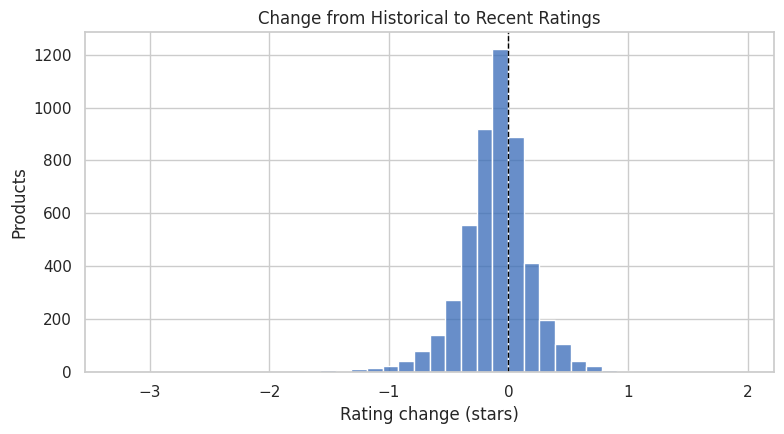

In [ ]:
trend_pd = (eligible_products
    .filter(F.col("historical").isNotNull() & F.col("recent").isNotNull())
    .orderBy(F.desc("review_count"))
    .limit(5000)
    .select("rating_change")
    .toPandas())

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(data=trend_pd, x="rating_change", bins=40, color="#3569b7", ax=ax)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set(title="Change from Historical to Recent Ratings", xlabel="Rating change (stars)", ylabel="Products")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "part2_rating_change_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## Interpretation and limitations

Products with high risk scores should be investigated first, but a high score does **not** prove that a product is defective.

- **Business value:** retailers and manufacturers can use the ranking to identify products that may need further investigation. They can then read the reviews, check product information and compare other business data.
- **Consumer value:** finding repeated customer problems earlier may improve product quality and help customers make better decisions.
- **Not causal:** the analysis shows patterns and associations. It does not prove that a product caused a reported problem.
- **Review bias:** reviews are voluntary, so they may not represent all customers. Ratings and helpful votes may also be affected by fake, repeated or coordinated reviews.
- **Dataset coverage:** the analysis uses a 3 GiB sequential subset rather than the full category dataset, so the results may differ from the full dataset.
- **Product IDs:** a parent ASIN may include product variants or may be affected by listing changes.
- **Time:** 2023 is incomplete. Rating change is meaningful only when a product has reviews in both the historical and recent periods. If one period is missing, the risk score adds no rating-change penalty.

The risk score should therefore be used to **prioritise products for investigation**, not as proof of a product problem. Human review of the review text and other business information is still needed before action is taken.


## Save the results

The small result files and figures are saved so that they can be added to GitHub.

The large raw and processing datasets are not uploaded because of their size and data-use restrictions.


In [ ]:
top_risk_pd = top_risk.toPandas()
top_risk_pd.to_csv(OUTPUT_DIR / "part2_top_risk_products.csv", index=False)
rating_bands.toPandas().to_csv(OUTPUT_DIR / "part2_rating_bands.csv", index=False)

part2_evidence = {
    "central_question": "Which products show the highest customer risk when we consider the number of reviews, negative reviews, helpful votes on negative reviews, and changes in ratings over time?",
    "processing_file_bytes": processing_bytes,
    "processing_rows": processing_rows,
    "minimum_reviews_for_ranking": 50,
    "eligible_products": eligible_count,
    "mapreduce_validation_mismatches": mismatch_count,
    "risk_score_definition": "negative_share * log1p(review_count) * (1 + log1p(negative_helpful_votes)) * (1 + max(-rating_change, 0))",
    "period_definition": {"historical": "review_year <= 2020", "recent": "2021 <= review_year <= 2023 (partial 2023)"},
    "execution": execution_evidence,
    "limitations": [
        "Observational review data cannot establish causation.",
        "Voluntary reviews are not representative of all purchasers.",
        "The 3 GiB sequential prefix may not represent the complete category file.",
        "Parent-product identifiers can be affected by variants or listing merges.",
        "Helpful votes and ratings may be affected by platform incentives or manipulation.",
        "The 2023 period is incomplete in the processing data.",
    ],
}
(OUTPUT_DIR / "part2_evidence.json").write_text(
    json.dumps(part2_evidence, indent=2, default=str), encoding="utf-8"
)
print(json.dumps(part2_evidence, indent=2, default=str))

In [ ]:
import zipfile
from google.colab import files
ARTIFACT_ZIP = Path("/content/mit805_part2_artifacts.zip")
with zipfile.ZipFile(ARTIFACT_ZIP, "w", zipfile.ZIP_DEFLATED) as zf:
    for folder in (OUTPUT_DIR, FIGURE_DIR):
        for path in folder.glob("*"):
            if path.is_file():
                zf.write(path, path.relative_to(ROOT))
print(f"Packaged {ARTIFACT_ZIP.stat().st_size:,} bytes")
files.download(str(ARTIFACT_ZIP))